<a href="https://colab.research.google.com/github/anujithesh26-del/SIH-2026-AI-ML-ENABLED-SEAMLESS-NAVIGATION/blob/main/seamless%20navigation%20sensor%20sanity%20testing%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your Physics Toolbox CSV file.


Saving multi_1788245796.65373.csv to multi_1788245796.65373.csv
Uploaded file: multi_1788245796.65373.csv
Columns found: ['time', 'gFx', 'gFy', 'gFz', 'ax', 'ay', 'az', 'wx', 'wy', 'wz', 'Bx(µT)', 'By(µT)', 'Bz(µT)', 'latitude', 'longitude', 'altitude', 'speed']
Number of rows: 8589

                       time     gFx     gFy     gFz      ax      ay      az  \
0  2026-09-01T06:55:10.725Z  0.0000  0.0000  0.0000 -0.5303 -0.2533 -1.5959   
1  2026-09-01T06:55:10.731Z -0.1773 -0.9888 -0.4399 -0.5303 -0.2533 -1.5959   
2  2026-09-01T06:55:10.789Z -0.1682 -0.9695 -0.4122  0.2186  0.8140 -0.7501   
3  2026-09-01T06:55:10.790Z -0.1682 -0.9695 -0.4122  0.2186  0.8140 -0.7501   
4  2026-09-01T06:55:10.801Z -0.0548 -0.9077 -0.2039  0.2489  0.7905  0.0305   

       wx      wy      wz   Bx(µT)   By(µT)   Bz(µT)   latitude  longitude  \
0  0.1235 -0.0677 -0.1063 -36.9614 -25.0949 -26.5067  12.917531  77.623709   
1  0.1235 -0.0677 -0.1063 -36.9614 -25.0949 -26.5067  12.917531  77.623709   
2  0.2

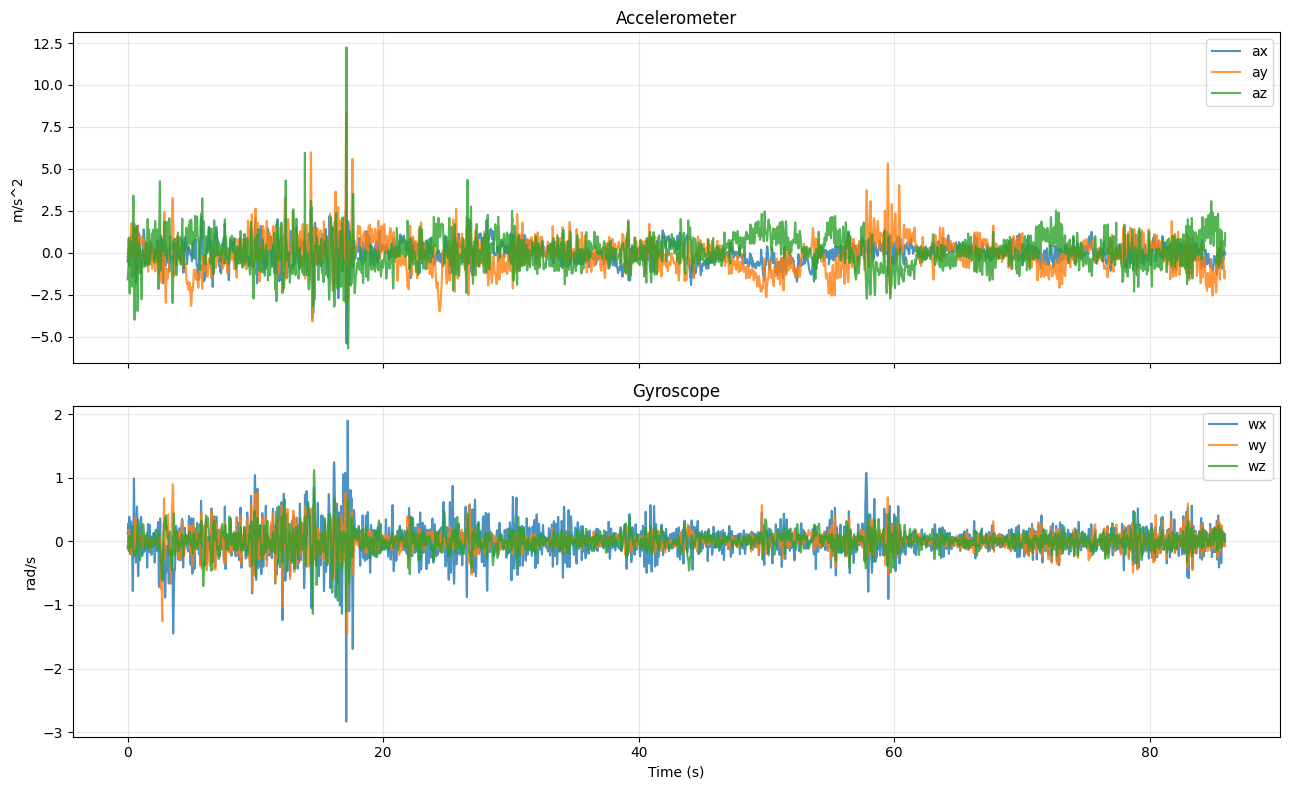

Raw g-force magnitude stats (should hover near 1.0 if gravity is included):
count    8589.000000
mean        1.005611
std         0.077979
min         0.000000
25%         0.965638
50%         1.004071
75%         1.041871
max         2.284134
dtype: float64
Actual recorded span: 85.9 seconds
Expected span if continuous: 85.9 seconds
Difference (likely gap time): 0.0 seconds

Looks continuous -- no major gap detected.


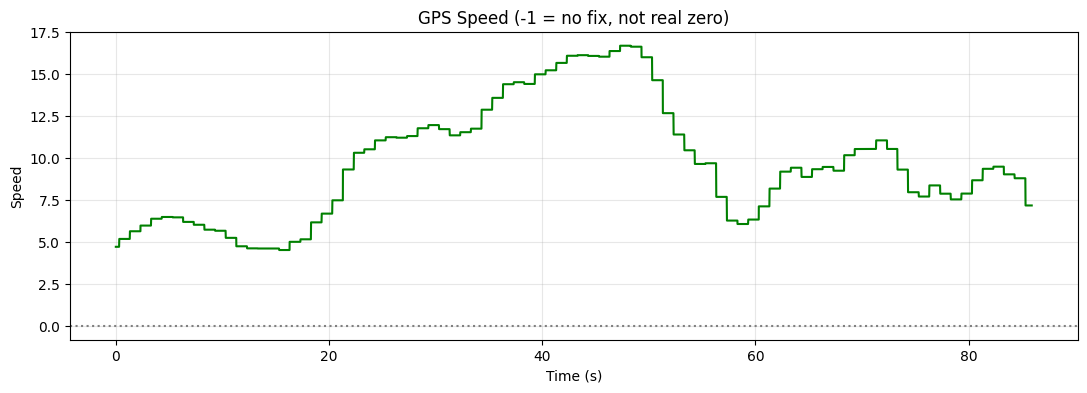

Number of 'no fix' samples (-1): 0 out of 8589


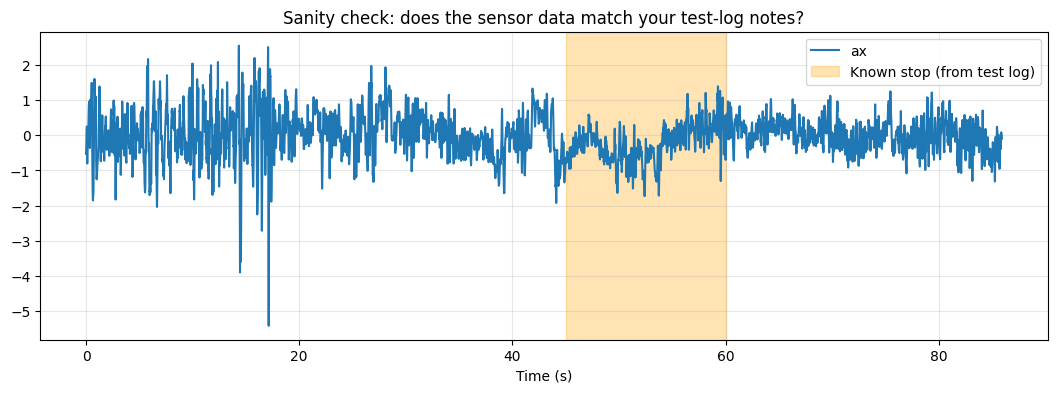

In [ ]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import io
from IPython.display import clear_output

clear_output(wait=True)

# Attempt to upload file
print("Please upload your Physics Toolbox CSV file.")
uploaded = files.upload()

# Get the filename from the uploaded dictionary
# Assuming only one file is uploaded.
if uploaded:
    filename = next(iter(uploaded))
    print(f"Uploaded file: {filename}")
else:
    print("No file uploaded. Please upload a file to proceed.")
    # We won't use sys.exit(1) as it kills the kernel in Colab,
    # instead we will just not call the analysis function.
    filename = None # Set filename to None to indicate no file was uploaded


def load_data(filename_or_buffer):
    """Physics Toolbox CSVs have one extra header line before the real columns."""
    # Read from the uploaded content using io.BytesIO
    if isinstance(filename_or_buffer, str) and filename_or_buffer in uploaded:
        df = pd.read_csv(io.BytesIO(uploaded[filename_or_buffer]), skiprows=1)
    else:
        raise ValueError("Invalid filename or buffer provided to load_data.")

    print("Columns found:", list(df.columns))
    print("Number of rows:", len(df))
    print()
    print(df.head())
    return df


def add_time_column(df):
    """Convert timestamp text into seconds elapsed since recording start."""
    # Ensure 'time' column exists before proceeding
    if 'time' not in df.columns:
        print("Error: 'time' column not found in the DataFrame. Cannot add time column.")
        return df # Return original df or raise error

    df['time'] = pd.to_datetime(df['time'])
    df['t_sec'] = (df['time'] - df['time'].iloc[0]).dt.total_seconds()
    print("Recording duration (seconds):", df['t_sec'].iloc[-1])
    return df


def check_sampling_rate(df):
    """Measure the real sampling rate and flag the biggest gap (possible dropout)."""
    # Ensure 't_sec' column exists before proceeding
    if 't_sec' not in df.columns:
        print("Error: 't_sec' column not found. Cannot check sampling rate.")
        return None # or raise an error

    time_diffs = df['t_sec'].diff()

    median_interval = time_diffs.median()
    print(f"Median sample interval: {median_interval:.4f} seconds")
    print(f"Estimated sampling rate: {1/median_interval:.1f} Hz")
    print()

    max_gap = time_diffs.max()
    max_gap_time = df['t_sec'].iloc[time_diffs.idxmax()]
    print(f"Biggest gap in recording: {max_gap:.3f} seconds, occurring at t={max_gap_time:.1f}s")
    print("(If this is much bigger than your median interval above, that's a dropout -- note it in your test log.)")

    return median_interval


def plot_accel_gyro(df):
    """Plot accelerometer and gyroscope axes stacked over time."""
    # Check for required columns
    required_accel_cols = ['t_sec', 'ax', 'ay', 'az']
    required_gyro_cols = ['t_sec', 'wx', 'wy', 'wz']

    if not all(col in df.columns for col in required_accel_cols + required_gyro_cols):
        print("Error: Missing accelerometer or gyroscope columns. Cannot plot.")
        return

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    axes[0].plot(df['t_sec'], df['ax'], label='ax', alpha=0.8)
    axes[0].plot(df['t_sec'], df['ay'], label='ay', alpha=0.8)
    axes[0].plot(df['t_sec'], df['az'], label='az', alpha=0.8)
    axes[0].set_title('Accelerometer')
    axes[0].set_ylabel('m/s^2')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(df['t_sec'], df['wx'], label='wx', alpha=0.8)
    axes[1].plot(df['t_sec'], df['wy'], label='wy', alpha=0.8)
    axes[1].plot(df['t_sec'], df['wz'], label='wz', alpha=0.8)
    axes[1].set_title('Gyroscope')
    axes[1].set_ylabel('rad/s')
    axes[1].set_xlabel('Time (s)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def check_raw_accel(df):
    """If gFx/gFy/gFz exist, check magnitude sits near 1.0 g (gravity included)."""
    if 'gFx' in df.columns and 'gFy' in df.columns and 'gFz' in df.columns:
        g_magnitude = (df['gFx']**2 + df['gFy']**2 + df['gFz']**2)**0.5
        print("Raw g-force magnitude stats (should hover near 1.0 if gravity is included):")
        print(g_magnitude.describe())
    else:
        print("No gFx/gFy/gFz columns in this file -- skip this check.")


def check_hidden_gaps(df, median_interval):
    """Compare claimed duration vs sample count to catch screen-lock/backgrounding gaps."""
    if 't_sec' not in df.columns or median_interval is None:
        print("Cannot check hidden gaps due to missing 't_sec' column or median_interval.")
        return

    expected_duration = len(df) * median_interval
    actual_duration = df['t_sec'].iloc[-1]

    print(f"Actual recorded span: {actual_duration:.1f} seconds")
    print(f"Expected span if continuous: {expected_duration:.1f} seconds")
    print(f"Difference (likely gap time): {actual_duration - expected_duration:.1f} seconds")

    if actual_duration - expected_duration > 5:
        print()
        print("WARNING: There's likely a significant gap in this recording (screen lock / app backgrounded).")
        print("Check the 'biggest gap' value above to find exactly when it happened.")
    else:
        print()
        print("Looks continuous -- no major gap detected.")


def plot_gps_speed(df):
    """Plot GPS speed. -1 means 'no fix', not real zero speed."""
    if 'speed' not in df.columns or 't_sec' not in df.columns:
        print("No 'speed' or 't_sec' column in this file -- skip this check.")
        return

    plt.figure(figsize=(13, 4))
    plt.plot(df['t_sec'], df['speed'], color='green')
    plt.axhline(0, color='gray', linestyle=':')
    plt.title('GPS Speed (-1 = no fix, not real zero)')
    plt.xlabel('Time (s)')
    plt.ylabel('Speed')
    plt.grid(alpha=0.3)
    plt.show()

    print("Number of 'no fix' samples (-1):", (df['speed'] == -1).sum(), "out of", len(df))


def mark_known_event(df, event_start, event_end, event_label="Known event (from test log)"):
    """Overlay a known event window from your test log onto the ax plot."""
    if 't_sec' not in df.columns or 'ax' not in df.columns:
        print("Cannot mark known event due to missing 't_sec' or 'ax' column.")
        return

    plt.figure(figsize=(13, 4))
    plt.plot(df['t_sec'], df['ax'], label='ax')
    plt.axvspan(event_start, event_end, color='orange', alpha=0.3, label=event_label)
    plt.legend()
    plt.title('Sanity check: does the sensor data match your test-log notes?')
    plt.xlabel('Time (s)')
    plt.grid(alpha=0.3)
    plt.show()


def run_analysis(filename_to_analyze):
    if filename_to_analyze is None:
        print("No file to analyze.")
        return

    try:
        df = load_data(filename_to_analyze)
        df = add_time_column(df)
        if 't_sec' not in df.columns:
             print("Time column not successfully added. Skipping further analysis.")
             return

        median_interval = check_sampling_rate(df)
        plot_accel_gyro(df)
        check_raw_accel(df)
        check_hidden_gaps(df, median_interval)
        plot_gps_speed(df)

        # EDIT these to match a real event time range from your test log (in seconds)
        event_start = 45
        event_end = 60
        mark_known_event(df, event_start, event_end, "Known stop (from test log)")

        # Quick reference, uncomment if useful:
        # print(df.describe())
        # df.to_csv('cleaned.csv', index=False)

    except Exception as e:
        print(f"An error occurred during analysis: {e}")


# Call the analysis function with the uploaded filename if it exists
run_analysis(filename)
